# EDA 개념과 데이터 구조 파악

In [1]:
# Titanic Dataset
# 다운로드 경로: https://www.kaggle.com/competitions/titanic/data?select=train.csv
# 다운로드 후 google drive에 원하는 위치에 업로드
# workspace/lecture/data/5W-EDA/titanic <- 제가 업로드한 위치
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
!ls /content/gdrive/MyDrive/workspace/lecture/data/5W-EDA/titanic

gender_submission.csv  test.csv  train.csv


In [3]:
import numpy as np
import pandas as pd

In [4]:
# dataset
df = pd.read_csv("/content/gdrive/MyDrive/workspace/lecture/data/5W-EDA/titanic/train.csv")

In [5]:
df.shape # row, column

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# 수치형 변수
print(df[["Age", "Fare"]][:5])
# 범주형 변수
print(df[["Survived", "Sex", "Embarked"]][:5])
# 순서형 변수
print(df[["Pclass"]][:5])

    Age     Fare
0  22.0   7.2500
1  38.0  71.2833
2  26.0   7.9250
3  35.0  53.1000
4  35.0   8.0500
   Survived     Sex Embarked
0         0    male        S
1         1  female        C
2         1  female        S
3         1  female        S
4         0    male        S
   Pclass
0       3
1       1
2       3
3       1
4       3


In [8]:
# 결측치 처리
print("결측치 처리 전 데이터프레임 행 수: ", df.shape[0])
df.isnull().sum() # -> 결측치의 갯수

결측치 처리 전 데이터프레임 행 수:  891


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
# 데이터 복사(원본 보존)
df_filled = df.copy()

# 수치형 변수 -> 중앙값으로 채우기
df_filled["Age"] = df_filled["Age"].fillna(df_filled["Age"].median())

# 범주형 변수 -> 새로운 카테고리 만들기; N=Unknown
df_filled["Cabin"] = df_filled["Cabin"].fillna("N")

# 결과확인
print("결측치 처리 후 데이터프레임 행 수: ", df_filled.shape[0])
df_filled.isnull().sum()

결측치 처리 후 데이터프레임 행 수:  891


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df_cleaned = df_filled.dropna()
# 결과확인
print("결측치 처리 후 데이터프레임 행 수: ", df_cleaned.shape[0])
df_cleaned.isnull().sum()

결측치 처리 후 데이터프레임 행 수:  889


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
# 이상치 처리

def detect_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25) # 1 분위수
  Q3 = df[column].quantile(0.75) # 3 분위수
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
  return outliers, lower_bound, upper_bound

print("이상치 확인 전 데이터프레임 행 수: ", df_cleaned.shape[0])

# Age 컬럼 이상치 탐색
age_outlier, age_lower, age_upper = detect_outliers_iqr(df_cleaned, "Age")
print(f"\nAge 컬럼 이상치 개수: {len(age_outlier)}")
print(f"Age 이상치 범위: {age_lower:.2f} ~ {age_upper:.2f}")

이상치 확인 전 데이터프레임 행 수:  889

Age 컬럼 이상치 개수: 65
Age 이상치 범위: 2.50 ~ 54.50


In [12]:
# Fare 컬럼 이상치 탐색
fare_outlier, fare_lower, fare_upper = detect_outliers_iqr(df_cleaned, "Fare")
print(f"\nAge 컬럼 이상치 개수: {len(fare_outlier)}")
print(f"Age 이상치 범위: {fare_lower:.2f} ~ {fare_upper:.2f}")


Age 컬럼 이상치 개수: 114
Age 이상치 범위: -26.76 ~ 65.66


In [13]:
# 이상치 삭제
initial_rows = df_cleaned.shape[0]

df_no_age_outlier = df_cleaned[(df_cleaned["Age"] >= age_lower) & (df_cleaned["Age"] <= age_upper)]

df_final = df_no_age_outlier[(df_no_age_outlier["Fare"] >= fare_lower) & (df_no_age_outlier["Fare"] <= fare_upper)]

print(f"이상치 삭제 전 데이터프레임 행 수: ", {initial_rows})
print(f"이상치 삭제 후 데이터프레임 행 수: ", {df_final.shape[0]})
print(f"제거된 이상치 행 수: ", {initial_rows - df_final.shape[0]})

df_final.head(5)

이상치 삭제 전 데이터프레임 행 수:  {889}
이상치 삭제 후 데이터프레임 행 수:  {721}
제거된 이상치 행 수:  {168}


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,N,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,N,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,N,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,N,Q


In [14]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 721 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  721 non-null    int64  
 1   Survived     721 non-null    int64  
 2   Pclass       721 non-null    int64  
 3   Name         721 non-null    object 
 4   Sex          721 non-null    object 
 5   Age          721 non-null    float64
 6   SibSp        721 non-null    int64  
 7   Parch        721 non-null    int64  
 8   Ticket       721 non-null    object 
 9   Fare         721 non-null    float64
 10  Cabin        721 non-null    object 
 11  Embarked     721 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 73.2+ KB


# 데이터 분포와 특성 분석

In [ ]:
# 수치형 변수의 분포 분석
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
print(f"수치형 변수: {list(numeric_cols)}\n") # PassengerId -> useless
numeric_cols = numeric_cols.drop("PassengerId")
print(f"수치형 변수: {list(numeric_cols)}\n")

stats_summary = df_final[numeric_cols].describe()
stats_summary

수치형 변수: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

수치형 변수: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']



,Survived,Pclass,Age,SibSp,Parch,Fare
count,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000
mean,0.337032,2.509015,28.094313,0.414702,0.323162,17.389845
std,0.473024,0.717046,10.021961,0.853916,0.788549,13.563036
min,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,0.000000,12.275000
75%,1.000000,3.000000,33.000000,1.000000,0.000000,26.000000
max,1.000000,3.000000,54.000000,5.000000,6.000000,65.000000


In [ ]:
# 평균과 중앙값 비교
num_df = df_final[numeric_cols]

mean = num_df.mean()
median = num_df.median()

# 차이 계산
diff = (mean - median).abs()
diff_ratio = (diff / mean * 100).round(1)

# 결과 정리
mean_median = pd.DataFrame({
    'mean': mean.round(2),
    'median': median.round(2),
    'difference': diff.round(2),
    'difference(%)': diff_ratio
})

print("[평균 vs 중앙값]")
print(mean_median)

"""
✔️ 데이터 전처리 관점

Fare, SibSp, Parch → 이상치/왜도 고려 필요

Age → 평균 대치 가능

Fare → 로그 변환 강력 추천

✔️ 모델링 관점

평균보다 중앙값이 대표적인 변수 다수

트리 계열 모델에 유리한 구조

✔️ EDA(탐색적 분석) 관점

“평균만 보면 오해할 수 있는 변수”를 식별한 분석
"""

[평균 vs 중앙값]
           mean  median  difference  difference(%)
Survived   0.34    0.00        0.34          100.0
Pclass     2.51    3.00        0.49           19.6
Age       28.09   28.00        0.09            0.3
SibSp      0.41    0.00        0.41          100.0
Parch      0.32    0.00        0.32          100.0
Fare      17.39   12.28        5.11           29.4


In [ ]:
# 분산과 표준편차
num_df = df_final[numeric_cols]

var = num_df.var()
std = num_df.std()

var_std = pd.DataFrame({
    'mean': mean,
    'var': var,
    'std': std
}).round(2)

print("[분산 · 표준편차]")
print(var_std)

[분산 · 표준편차]
           mean     var    std
Survived   0.34    0.22   0.47
Pclass     2.51    0.51   0.72
Age       28.09  100.44  10.02
SibSp      0.41    0.73   0.85
Parch      0.32    0.62   0.79
Fare      17.39  183.96  13.56


In [ ]:
# 왜도와 첨도
skew_kurt = df_final[numeric_cols].agg(["skew", "kurtosis"]).T.round(2)

print("[왜도, 첨도]")
print(skew_kurt)

# 해석 기준:
# 왜도: 0에 가까울수록 대칭
# 첨도: 0에 가까울수록 정규분포와 유사. 첨도 > 0: 뾰족함, 첨도 < 0: 평평함.

[왜도, 첨도]
          skew  kurtosis
Survived  0.69     -1.53
Pclass   -1.11     -0.20
Age       0.13      0.47
SibSp     2.88      9.42
Parch     3.31     13.76
Fare      1.52      1.73


In [15]:
# 범주형 변수 분포 분석
categorical_cols = df_final.select_dtypes(include=["object", "category"]).columns
# Name -> useless
categorical_cols = categorical_cols.drop("Name")

for col in categorical_cols:
  print(f"\n[{col}]")
  counts = df_final[col].value_counts()
  ratio = df_final[col].value_counts(normalize=True) * 100

  freq_df = pd.DataFrame({
      'count': counts,
      'ratio(%)': ratio.round(1)
  })

  print(freq_df[:5])


[Sex]
        count  ratio(%)
Sex                    
male      490      68.0
female    231      32.0

[Ticket]
            count  ratio(%)
Ticket                     
1601            7       1.0
347082          6       0.8
CA 2144         5       0.7
347088          5       0.7
W./C. 6608      4       0.6

[Cabin]
       count  ratio(%)
Cabin                 
N        623      86.4
F33        3       0.4
G6         3       0.4
D          3       0.4
E101       3       0.4

[Embarked]
          count  ratio(%)
Embarked                 
S           545      75.6
C           105      14.6
Q            71       9.8


In [17]:
df_final['Cabin'].value_counts()

,count
Cabin,
N,623
F33,3
G6,3
D,3
E101,3
...,...
E17,1
A24,1
B51 B53 B55,1


In [18]:
# 파생 변수 생성
df_final['Deck'] = df_final['Cabin'].str[0]
df_final['Deck'] = df_final['Deck'].fillna('N')
print('[Deck 분포]')
print(df_final['Deck'].value_counts())

[Deck 분포]
Deck
N    623
E     24
C     19
D     17
B     13
F     11
A     10
G      3
T      1
Name: count, dtype: int64


/tmp/ipython-input-875539503.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Deck'] = df_final['Cabin'].str[0]
/tmp/ipython-input-875539503.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Deck'] = df_final['Deck'].fillna('N')


In [ ]:
# ticket
df_final['Ticket_Group'] = df_final.groupby('Ticket')['Ticket'].transform('count')
print("\n[Ticket Group 예시]")
print(df_final[['Ticket', 'Ticket_Group']].head())


[Ticket Group 예시]
             Ticket  Ticket_Group
0         A/5 21171             1
2  STON/O2. 3101282             1
3            113803             2
4            373450             1
5            330877             1


/tmp/ipython-input-914174890.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Ticket_Group'] = df_final.groupby('Ticket')['Ticket'].transform('count')


In [ ]:
df_final['Ticket_Group'].value_counts()

,count
Ticket_Group,
1,516
2,128
3,30
4,24
5,10
7,7
6,6


# 3. 변수 간 관계 분석

In [ ]:
# 피어슨 상관계수
corr = df_final[numeric_cols].corr() # 상관계수 행렬
print('[상관계수 행렬]')
print(corr.round(2))

[상관계수 행렬]
          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.27 -0.06   0.00   0.08  0.26
Pclass       -0.27    1.00 -0.30   0.08   0.06 -0.59
Age          -0.06   -0.30  1.00  -0.28  -0.12  0.10
SibSp         0.00    0.08 -0.28   1.00   0.39  0.37
Parch         0.08    0.06 -0.12   0.39   1.00  0.34
Fare          0.26   -0.59  0.10   0.37   0.34  1.00


In [ ]:
# 절댓값 0.3 이상인 상관관계만 추출
threshold = 0.3
print("\n[주요 상관관계]")

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        value = corr.iloc[i, j]
        if abs(value) >= threshold:
            print(f"{corr.columns[i]} ↔ {corr.columns[j]} : {value:.2f}")


[주요 상관관계]
Pclass ↔ Age : -0.30
Pclass ↔ Fare : -0.59
SibSp ↔ Parch : 0.39
SibSp ↔ Fare : 0.37
Parch ↔ Fare : 0.34


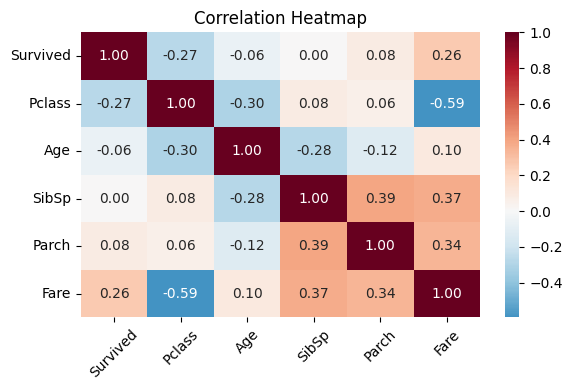

In [ ]:
# 상관계수 히트맵 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.xticks(rotation=45)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# 스피어만 상관계수
corr_spearman = df_final[numeric_cols].corr(method="spearman")

print("[스피어만 상관계수 행렬]")
print(corr_spearman.round(2))

[스피어만 상관계수 행렬]
          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.28 -0.04   0.08   0.14  0.26
Pclass       -0.28    1.00 -0.28  -0.01   0.01 -0.56
Age          -0.04   -0.28  1.00  -0.12  -0.18  0.10
SibSp         0.08   -0.01 -0.12   1.00   0.45  0.47
Parch         0.14    0.01 -0.18   0.45   1.00  0.43
Fare          0.26   -0.56  0.10   0.47   0.43  1.00


In [20]:
print("[피어슨-스피어만 차이]")
diff = (corr - corr_spearman).abs()
print(diff.round(2))

"""
이 표는 변수 쌍 간 관계가 ‘선형’인지, 아니면 ‘순위 기반 단조 관계’인지를
피어슨–스피어만 상관계수 차이로 진단한 분석이며,
비선형성·이상치 영향·모델 적합성 판단을 위한 고급 EDA 결과입니다.
"""

[피어슨-스피어만 차이]


NameError: name 'corr' is not defined

[상관관계가 높은 컬럼 3쌍]
Pclass ↔ Fare
SibSp ↔ Parch
SibSp ↔ Fare


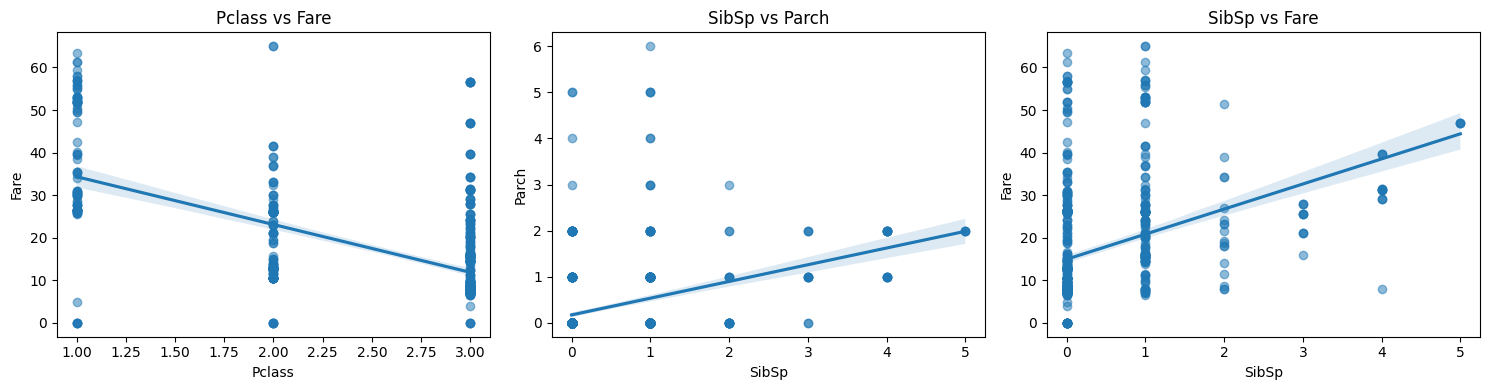

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ 상관계수 절댓값 기준 상위 3쌍 선택
corr_abs = corr.abs()
corr_abs.values[np.tril_indices_from(corr_abs)] = 0

top3 = (
    corr_abs
    .stack()
    .sort_values(ascending=False)
    .head(3)
)

print("[상관관계가 높은 컬럼 3쌍]")
for (v1, v2), _ in top3.items():
    print(f"{v1} ↔ {v2}")

# 2️⃣ 산점도 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (v1, v2) in zip(axes, top3.index):
    sns.regplot(data=df_final, x=v1, y=v2, ax=ax, scatter_kws={'alpha':0.5})
    ax.set_title(f"{v1} vs {v2}")

plt.tight_layout()
plt.show()

In [ ]:
# 범주형 - 범주형 변수 분석
from scipy.stats import chi2_contingency

# 분석할 범주형 변수 2개 선택
# 1: Sex, 2: Survived
# 컬럼 확인: df_final.columns

# 교차표
table = pd.crosstab(df_final['Sex'], df_final['Survived'])
print("[교차표]")
print(table)

[교차표]
Survived    0    1
Sex               
female     72  159
male      406   84


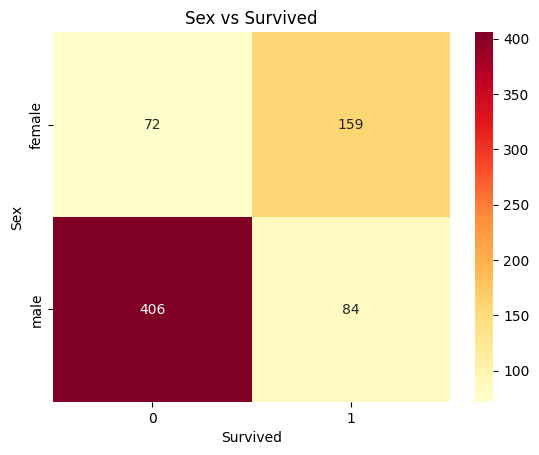

In [ ]:
sns.heatmap(table, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Sex vs Survived")
plt.show()

In [ ]:
numeric_cols

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [ ]:
# 범주형 - 수치형: 그룹분석

# 분석할 변수 선택 => 성별에 따른 나이 분석
cat = "Sex"
num = "Age"

group_stats = (
    df_final.groupby(cat)[num].agg(["count", "mean"]).round(2)
)

print("[성별에 따른 나이 분석]")
print(group_stats)

[성별에 따른 나이 분석]
        count   mean
Sex                 
female    231  26.76
male      490  28.72
